In [22]:
import json

# 假设你有一个名为 'data.json' 的 JSON 文件
file_path = '/data/songziying/workspace/SparseDrive/data/cross/val_llava_one_frame.json'

# 打开并读取 JSON 文件
with open(file_path, 'r', encoding='utf-8') as file:
    data = json.load(file)

# 打印加载的 JSON 数据
# print(data)

In [27]:
# build token2image
import os
directory_path = '/data/songziying/workspace/SparseDrive/data/nuscenes/samples/CAM_FRONT'
file_list = os.listdir(directory_path)
# 获取完整的文件路径
file_paths = [os.path.join(directory_path, filename) for filename in file_list]
# 打印完整文件路径
print(len(file_paths)) # 40157条数据
timestamp_to_filepath = {}
for file_path in file_paths:
    timestamp = file_path.split('_')[-1][:-4]
    timestamp_to_filepath[timestamp] = file_path
#build key frame json file
nuscences_json_file = "/data/songziying/workspace/SparseDrive/data/nuscenes/v1.0-trainval/sample_data.json"
with open(nuscences_json_file, 'r') as json_file:
    nuscences_data = json.load(json_file)
nuscences_data_with_key_frame = []
for enrty in nuscences_data:
    dict = {}
    if enrty['is_key_frame'] == True and enrty['fileformat'] == 'jpg':
        dict['sample_token'] = enrty['sample_token']
        dict['filename'] =  enrty['filename']
        nuscences_data_with_key_frame.append(dict)
print(len(nuscences_data_with_key_frame))
token_to_filename = {}
for enrty in nuscences_data_with_key_frame:
     if enrty['filename'][:18] == 'samples/CAM_FRONT/':
         token_to_filename[enrty['sample_token']]= enrty['filename']
print(len(token_to_filename)) 

40157
204894
34149


In [25]:
filename_to_token = {value: key for key, value in token_to_filename.items()}
part_to_remove = "/data/songziying/workspace/SparseDrive/data/nuscenes"
modified_string = data[0]['image'].replace(part_to_remove, "")
modified_string

'/samples/CAM_FRONT/n008-2018-08-01-15-16-36-0400__CAM_FRONT__1533151514512404.jpg'

In [23]:
import ast
import numpy as np
image_paths = []
trajs = []
for i in range(len(data)):
    text = data[i]['conversations'][1]['value']
    infos = text.split("\n")
    #print(infos)
    traj = infos[-1] 
    traj = ast.literal_eval(traj)
    traj = np.array(traj)
    part_to_remove = "/data/songziying/workspace/SparseDrive/data/nuscenes"
    image_path = data[i]['image'].replace(part_to_remove, "")
    trajs.append(traj)
    image_paths.append(image_path)

In [29]:
filename_to_token

{'samples/CAM_FRONT/n015-2018-07-18-11-07-57+0800__CAM_FRONT__1531883531412477.jpg': 'ae4e0c3aa3f24c91aab599e8b54e9264',
 'samples/CAM_FRONT/n015-2018-07-18-11-07-57+0800__CAM_FRONT__1531883530412470.jpg': 'e93e98b63d3b40209056d129dc53ceee',
 'samples/CAM_FRONT/n015-2018-07-18-11-07-57+0800__CAM_FRONT__1531883532412464.jpg': 'ba94cb79ebc74614bc2442185cb53c26',
 'samples/CAM_FRONT/n015-2018-07-18-11-07-57+0800__CAM_FRONT__1531883530912460.jpg': '14d5adfe50bb4445bc3aa5fe607691a8',
 'samples/CAM_FRONT/n015-2018-07-18-11-07-57+0800__CAM_FRONT__1531883535412467.jpg': '917a76cd5f564387bcacc22537010630',
 'samples/CAM_FRONT/n015-2018-07-18-11-07-57+0800__CAM_FRONT__1531883531912467.jpg': '8de7ec06e1ac48c689c4d24d6cc64fd7',
 'samples/CAM_FRONT/n015-2018-07-18-11-07-57+0800__CAM_FRONT__1531883534412469.jpg': '1e19d0a5189b46f4b62aa47508f2983e',
 'samples/CAM_FRONT/n015-2018-07-18-11-07-57+0800__CAM_FRONT__1531883533012462.jpg': '4dfab70f0b3f405bbf17f7c534d2dd91',
 'samples/CAM_FRONT/n015-2018-07

In [30]:
tokens = []
for i in range(5119):
    tokens.append(filename_to_token[image_paths[i][1:]])

In [50]:
selected_tokens = []
selected_ids = []
for i in range(5119):
    if np.abs(trajs[i][5,0]) > 8:
        selected_tokens.append(tokens[i])
        selected_ids.append(i)

In [51]:
len(selected_tokens)

56

In [52]:
selected_tokens

['e693989d8ad141608999200df71aca71',
 'bf3b9da1e7054458851f93f4a44ffb9c',
 '2beac07fddfa49f38f5380f1ae761d6d',
 'b8fd81311abd466b9975a21f69d8c357',
 '81f68870ae19470a93ae51e7ff2583ef',
 '5f52fc6688cd4b098799012ee6a04875',
 '03e1fa4ec2664a34987dcc8c2898d94d',
 '73d95c15de79498fbca3d12815f43376',
 'b380f7433ef54209be12e5f830b1126c',
 '6c8d4379e83646d08436f6ec92b35fe5',
 'b731e3bfd7b64247b9d9708e67847933',
 '0e4aea0d177c480a9ae050a01368ebde',
 'ed8368b711934a1b86f5a4ce354c39b0',
 '740e48ba5a5a45afbc1a56b16f586054',
 '6060fa4c3b1e443994967da28e86132b',
 '029a6b83ae1a42cbbf775fd77415745f',
 'eb5ea93bd45246329e50a6d7a93e3832',
 '5bb77a2ff3d44094b691ba239cbab83a',
 'b1303058fa624645b753d7283d70de45',
 'a19a80c905674faab7203a3a4e0f5246',
 'ce3718b3d5a4404c80b724e1b15cf7bf',
 'f868336acfca41f6b3b7a3d1b6518691',
 'a5f8715674ad4460b583cf6067096e5b',
 '5961c01ec5e04ee48959a30d2b337c57',
 'ac54c36b81eb498a810587527ff58ac8',
 'f3b10b3ae50a4ada8ad177f61b3138f5',
 '93ca32c6f20745cd9d6010c66a2721c8',
 

In [53]:
with open('selected_tokens.json', 'w', encoding='utf-8') as f:
    json.dump(selected_tokens, f, ensure_ascii=False, indent=4)

In [44]:
selected_ids

[34,
 35,
 36,
 37,
 38,
 196,
 197,
 198,
 199,
 200,
 201,
 202,
 203,
 340,
 341,
 400,
 401,
 402,
 403,
 404,
 405,
 406,
 468,
 469,
 470,
 471,
 472,
 473,
 474,
 564,
 565,
 566,
 567,
 568,
 569,
 570,
 571,
 647,
 648,
 649,
 650,
 878,
 879,
 880,
 881,
 882,
 883,
 884,
 885,
 886,
 887,
 990,
 991,
 992,
 1001,
 1002,
 1003,
 1004,
 1005,
 1006,
 1007,
 1024,
 1127,
 1128,
 1129,
 1160,
 1161,
 1162,
 1163,
 1640,
 1641,
 1642,
 1643,
 1644,
 1916,
 1917,
 1918,
 1919,
 1920,
 1921,
 2258,
 2259,
 2260,
 2261,
 2262,
 2263,
 2272,
 2273,
 2274,
 2275,
 2276,
 2277,
 2278,
 2279,
 2330,
 2331,
 2332,
 2333,
 2334,
 2335,
 2336,
 2337,
 2338,
 2422,
 2423,
 2424,
 2425,
 3003,
 3004,
 3085,
 3086,
 3087,
 3088,
 3089,
 3267,
 3268,
 3269,
 3280,
 3281,
 3282,
 3371,
 3372,
 3373,
 3374,
 3375,
 3376,
 3757,
 3758,
 3759,
 3760,
 3761,
 3762,
 3763,
 3764,
 3775,
 3776,
 3777,
 3778,
 3779,
 3780,
 3781,
 3926,
 3927,
 3928,
 3962,
 3963,
 3964,
 3965,
 3966,
 3967,
 3968,
 4

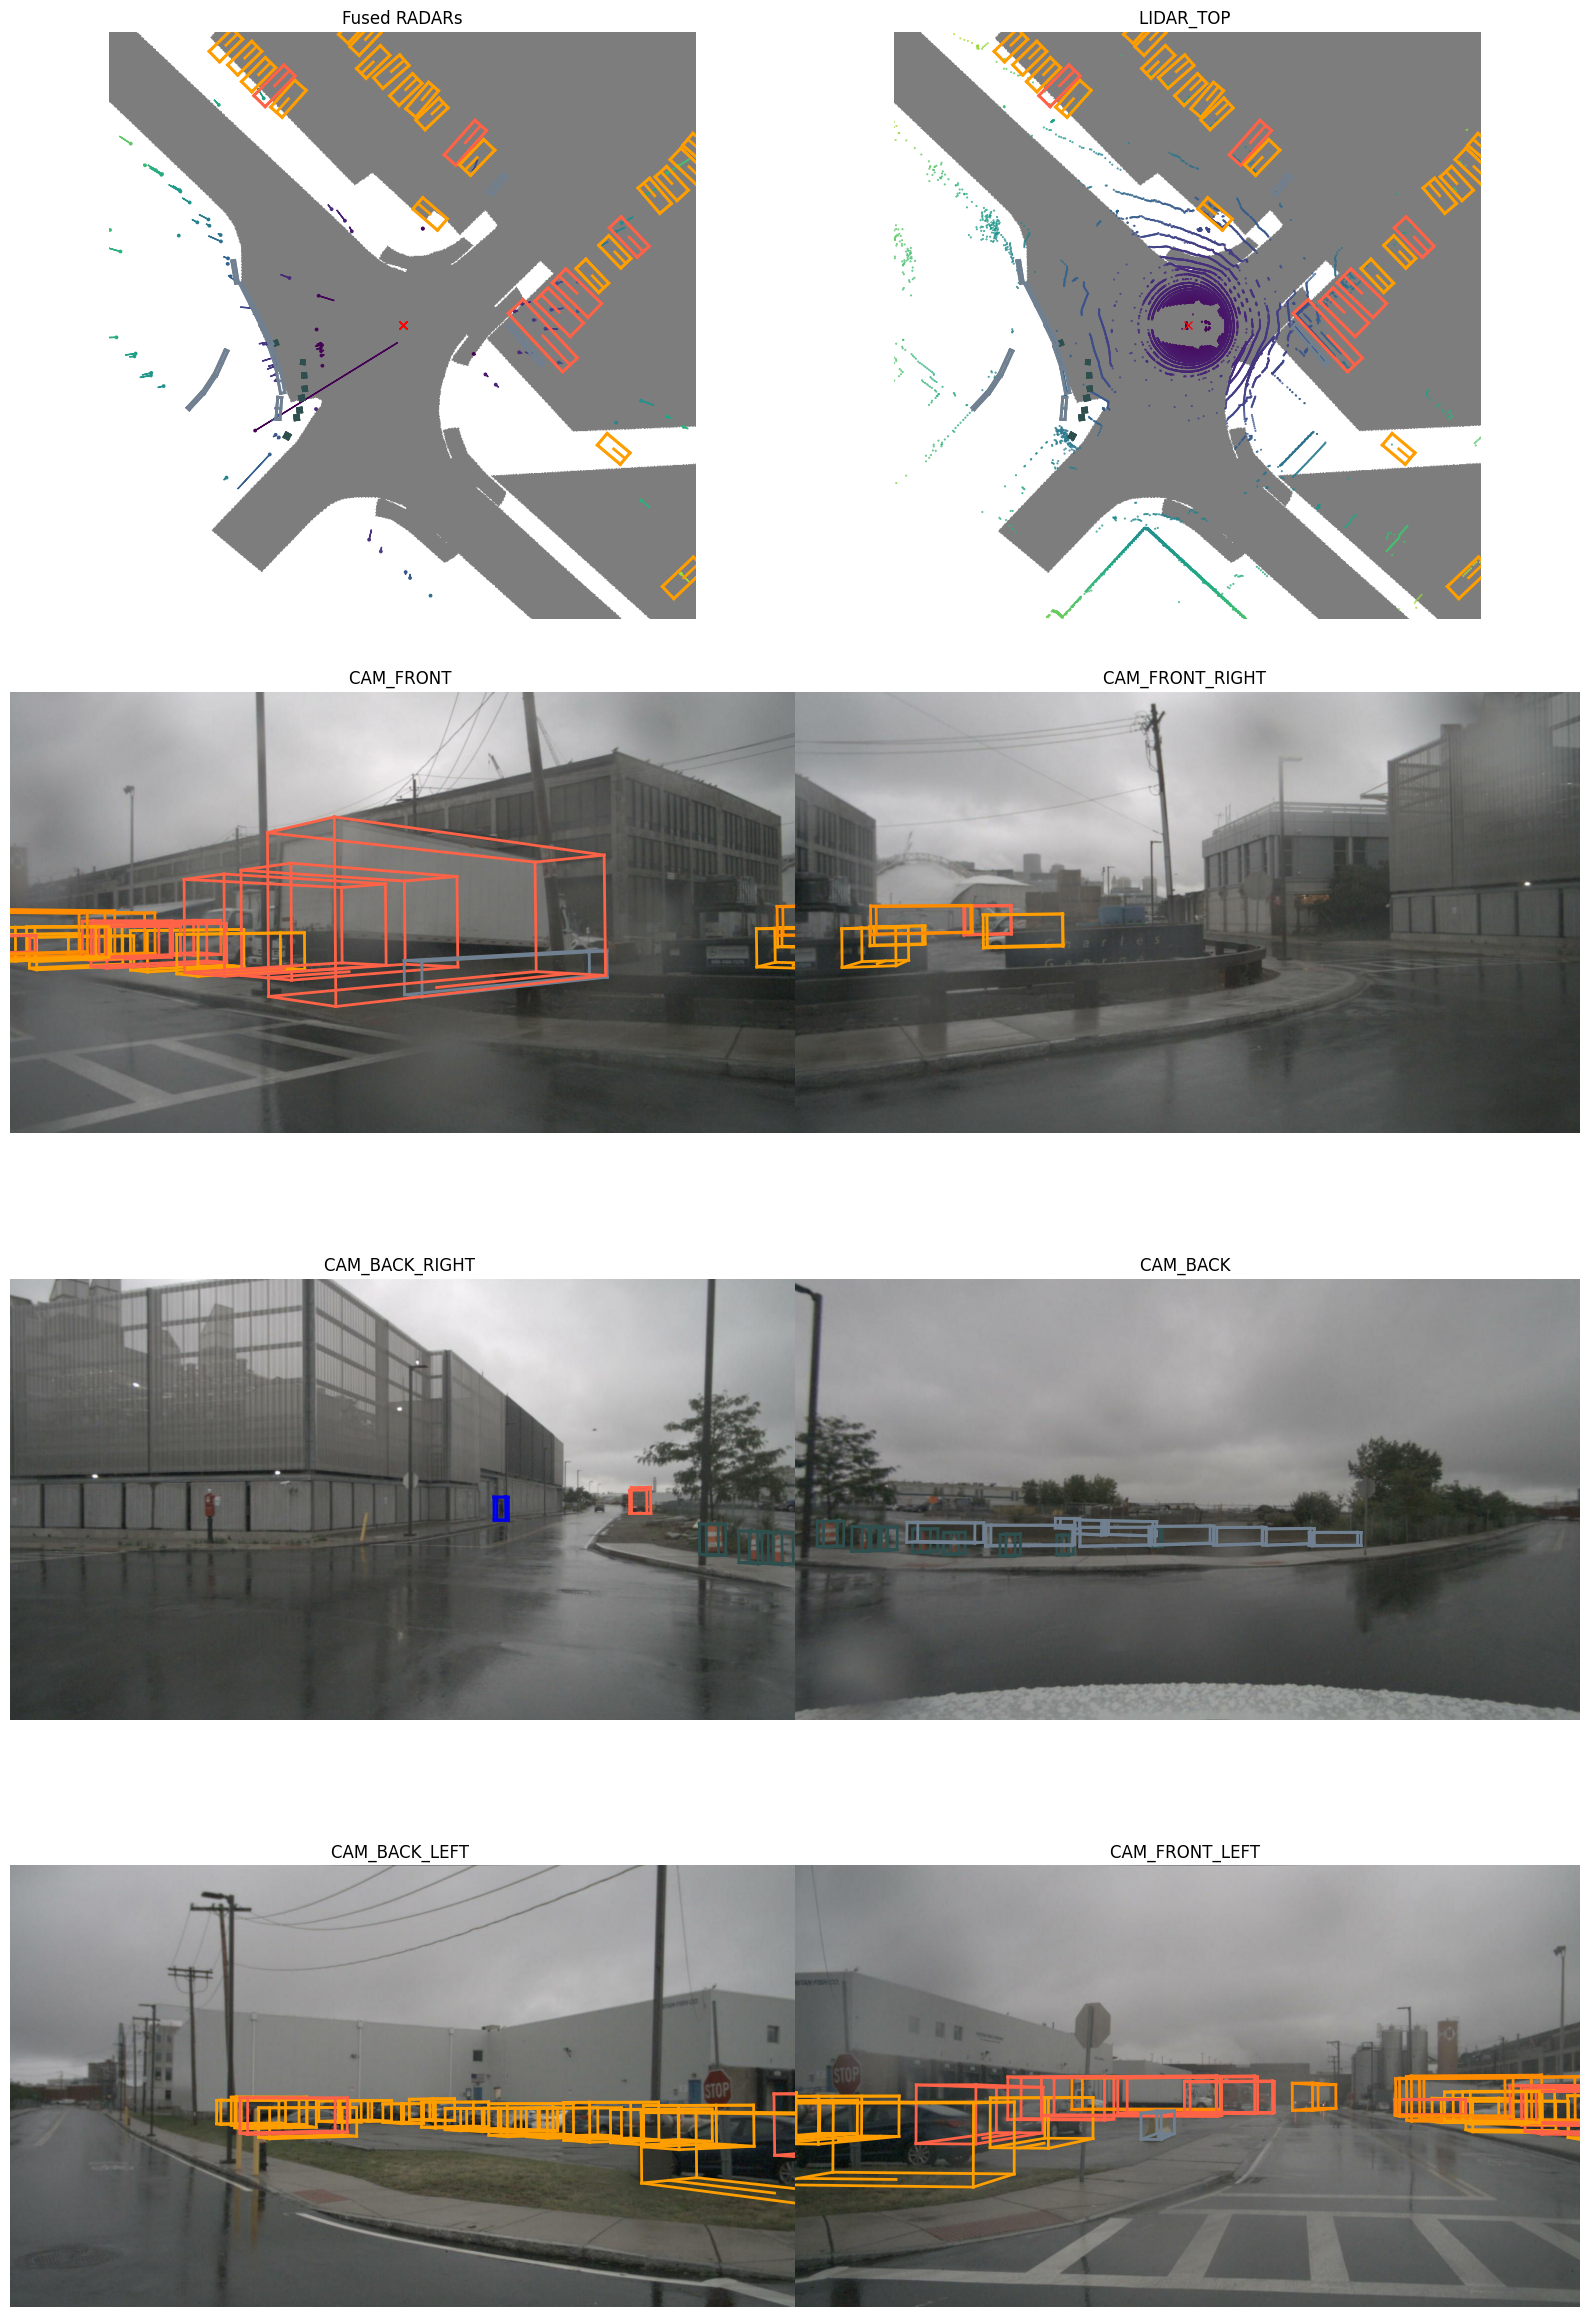

In [45]:
nusc.render_sample(selected_tokens[100])

In [ ]:
from nuscenes.nuscenes import NuScenes
nusc = NuScenes(version='v1.0-trainval', dataroot="/data/songziying/workspace/SparseDrive/data/nuscenes", verbose=True)

In [ ]:
#data = nusc.get('sample', selected_tokens[61])
nusc.render_sample('3613b5ea52bc46d0966fede34be89d38')

In [ ]:
data_next2 = nusc.get('sample', data_next['next'])

In [ ]:
data['next']

In [ ]:
nusc.render_sample(data['next'])

In [ ]:
nusc.render_sample(data['next'])